In [144]:
import pandas as pd
from pathlib import Path

# Display all column names
filename = "compas_two_year_recidivism.csv"
project_dir = Path(r"C:\Users\ASUS\Desktop\Tópicos exploratórios\ETAI-Pipeline-1\data")

candidates = [
    Path.cwd() / filename,
    project_dir / filename,
]

csv_path = next((path for path in candidates if path.is_file()), None)

if csv_path is None:
    raise FileNotFoundError(
        f"Could not find {filename}. Place it in {project_dir} "
        "or update the file path."
    )

compas_two_year_recidivism = pd.read_csv(csv_path)

# Display all column names
print(compas_two_year_recidivism.columns.tolist())

['juv_other_count', 'score_text', 'priors_count', 'juv_misd_count', 'juvenile_total', 'sex', 'age_cat', 'id', 'c_charge_degree', 'two_year_recid', 'juv_fel_count', 'age_in_months', 'race', 'prior_offenses', 'age', 'decile_score']


## Valores em falta (missingness)

`isna()` conta apenas valores ausentes reconhecidos pelo pandas. Primeiro, vamos também procurar os marcadores textuais `-` e `?` sem alterar o DataFrame. Depois, comparamos a ausência de `race` entre subgrupos definidos por variáveis observadas. Diferenças podem indicar que a ausência não é MCAR; não demonstram por si só MAR, e MNAR não pode ser distinguido de MAR apenas observando estes dados.

In [145]:
missing_tokens = {"-", "?"}
missing_rows = []

for column in compas_two_year_recidivism.columns:
    values = compas_two_year_recidivism[column]
    text_values = values.astype("string").str.strip().str.lower()
    token_counts = {
        token: int(text_values.eq(token).fillna(False).sum())
        for token in missing_tokens
    }
    missing_rows.append(
        {
            "coluna": column,
            "NaN": int(values.isna().sum()),
            "'-'": token_counts["-"],
            "'?'": token_counts["?"],
            "total_missing": int(values.isna().sum()) + sum(token_counts.values()),
        }
    )

missing_summary = pd.DataFrame(missing_rows).set_index("coluna")
missing_summary["percentual_missing"] = (
    100 * missing_summary["total_missing"] / len(compas_two_year_recidivism)
).round(2)
display(missing_summary.sort_values("total_missing", ascending=False))


,NaN,'-','?',total_missing,percentual_missing
coluna,,,,,
priors_count,420,81,0,501,6.88
prior_offenses,420,81,0,501,6.88
c_charge_degree,233,0,0,233,3.20
juv_fel_count,217,0,0,217,2.98
age_in_months,146,0,0,146,2.00
age,146,0,0,146,2.00
race,0,72,72,144,1.98
sex,60,0,49,109,1.50
id,0,0,0,0,0.00


In [146]:
with pd.option_context("display.max_columns", None):
    display(compas_two_year_recidivism.head())

,juv_other_count,score_text,priors_count,juv_misd_count,juvenile_total,sex,age_cat,id,c_charge_degree,two_year_recid,juv_fel_count,age_in_months,race,prior_offenses,age,decile_score
0,1,Low,0.0,0,1.0,Male,25 - 45,8423,F,0,0.0,324.0,African-American,0.0,27.0,2
1,0,High,3.0,0,0.0,Male,Less than 25,4137,M,1,0.0,276.0,Caucasian,3.0,23.0,8
2,0,Low,2.0,0,0.0,male,25 - 45,5064,F,1,0.0,336.0,Caucasian,2.0,28.0,2
3,0,High,2.0,0,0.0,female,Less than 25,56,F,0,NaN,252.0,African-American,2.0,21.0,8
4,0,Low,1.0,0,0.0,Male,25 - 45,9369,M,0,0.0,372.0,African-American,1.0,31.0,4


In [147]:
# Verificar valores distintos nas features categóricas
categorical_columns = compas_two_year_recidivism.select_dtypes(
    include=["object", "category"]
).columns

for column in categorical_columns:
    values = compas_two_year_recidivism[column].dropna().astype(str)
    normalized_values = values.str.strip().str.lower()

    print(f"\nFeature: {column}")
    print("Valores originais:")
    display(values.value_counts().to_frame("frequência"))

    inconsistencies = (
        pd.DataFrame({"original": values, "normalizado": normalized_values})
        .groupby("normalizado")["original"]
        .unique()
    )

    inconsistencies = inconsistencies[
        inconsistencies.apply(lambda x: len(x) > 1)
    ]

    if not inconsistencies.empty:
        print("Possíveis inconsistências:")
        display(inconsistencies.to_frame("variações"))


Feature: score_text
Valores originais:


C:\Users\ASUS\AppData\Local\Temp\ipykernel_36240\2429336475.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = compas_two_year_recidivism.select_dtypes(


,frequência
score_text,
Low,3701
Medium,1813
High,1330
low,112
LOW,111
MEDIUM,64
medium,63
high,56
HIGH,36


Possíveis inconsistências:


,variações
normalizado,
high,"[High, HIGH, high]"
low,"[Low, low, LOW]"
medium,"[Medium, medium, MEDIUM]"


...

,frequência
race,
African-American,3426
Caucasian,2295
Hispanic,591
Other,376
?,72
-,72
African-American,64
African American,61
african-american,58


Possíveis inconsistências:


,variações
normalizado,
african-american,"[African-American, african-american, African-..."
caucasian,"[Caucasian, caucasian, CAUCASIAN, Caucasian]"
hispanic,"[Hispanic, HISPANIC, hispanic]"



Feature: prior_offenses
Valores originais:


,frequência
prior_offenses,
0.0,2009
1.0,1323
2.0,805
3.0,533
4.0,375
5.0,315
6.0,226
7.0,198
8.0,177


In [148]:
compas_normalizado = compas_two_year_recidivism.copy()

for coluna in compas_normalizado.select_dtypes(include=["object", "category"]).columns:
    compas_normalizado[coluna] = compas_normalizado[coluna].map(
        lambda valor: valor.strip().lower() if isinstance(valor, str) else valor
    )

colunas_sensiveis = ["sex", "race"]
tokens_ausentes = {"-", "?"}
sem_categoria_sensivel = compas_normalizado[colunas_sensiveis].apply(
    lambda coluna: (
        coluna.isna()
        | coluna.astype("string").str.strip().str.lower().isin(tokens_ausentes)
    )
).any(axis=1)

linhas_removidas = int(sem_categoria_sensivel.sum())
compas_normalizado = compas_normalizado.loc[~sem_categoria_sensivel].copy()

print(f"Linhas removidas por ausência em sex ou race: {linhas_removidas}")
print(f"Linhas restantes: {len(compas_normalizado)}")

with pd.option_context("display.max_columns", None):
    display(compas_normalizado.head())

Linhas removidas por ausência em sex ou race: 252
Linhas restantes: 7034


C:\Users\ASUS\AppData\Local\Temp\ipykernel_36240\818876696.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for coluna in compas_normalizado.select_dtypes(include=["object", "category"]).columns:


,juv_other_count,score_text,priors_count,juv_misd_count,juvenile_total,sex,age_cat,id,c_charge_degree,two_year_recid,juv_fel_count,age_in_months,race,prior_offenses,age,decile_score
0,1,low,0.0,0,1.0,male,25 - 45,8423,f,0,0.0,324.0,african-american,0.0,27.0,2
1,0,high,3.0,0,0.0,male,less than 25,4137,m,1,0.0,276.0,caucasian,3.0,23.0,8
2,0,low,2.0,0,0.0,male,25 - 45,5064,f,1,0.0,336.0,caucasian,2.0,28.0,2
3,0,high,2.0,0,0.0,female,less than 25,56,f,0,NaN,252.0,african-american,2.0,21.0,8
4,0,low,1.0,0,0.0,male,25 - 45,9369,m,0,0.0,372.0,african-american,1.0,31.0,4


In [149]:
# Valores fora do domínio válido

# decile_score: deve estar entre 1 e 10
decile_numeric = pd.to_numeric(compas_normalizado["decile_score"], errors="coerce")
decile_invalidos = compas_normalizado[
    decile_numeric.notna() & ~decile_numeric.between(1, 10)
]

print("decile_score fora do intervalo [1, 10]:", len(decile_invalidos))
display(decile_invalidos[["decile_score"]].drop_duplicates())

# age: considerando plausível o intervalo de 18 a 100 anos
age_numeric = pd.to_numeric(compas_normalizado["age"], errors="coerce")
age_invalidas = compas_normalizado[
    age_numeric.notna() & ~age_numeric.between(18, 100)
]

print("Idades fora do intervalo [18, 100]:", len(age_invalidas))
display(age_invalidas[["age"]].drop_duplicates().sort_values("age"))

# Contagens: não devem ser negativas
count_columns = [
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
]

negative_counts = []

for column in count_columns:
    numeric_values = pd.to_numeric(
        compas_normalizado[column], errors="coerce"
    )
    invalid_count = (numeric_values < 0).sum()

    negative_counts.append(
        {
            "variável": column,
            "valores_negativos": int(invalid_count),
            "mínimo_observado": numeric_values.min(),
        }
    )

negative_counts_summary = pd.DataFrame(negative_counts)
display(negative_counts_summary)

decile_score fora do intervalo [1, 10]: 6


,decile_score
20,15
567,23
2321,0


Idades fora do intervalo [18, 100]: 8


,age
2307,-3.0
2047,5.0


,variável,valores_negativos,mínimo_observado
0,priors_count,0,0.0
1,juv_fel_count,5,-1.0
2,juv_misd_count,0,0.0
3,juv_other_count,0,0.0


In [150]:
# Comparar colunas numéricas sem alterar o DataFrame.
# Marcadores como "-" são convertidos em NaN para estas verificações.
dados = compas_normalizado

priors = pd.to_numeric(dados["priors_count"], errors="coerce")
prior_offenses = pd.to_numeric(dados["prior_offenses"], errors="coerce")

age = pd.to_numeric(dados["age"], errors="coerce")
age_in_months = pd.to_numeric(dados["age_in_months"], errors="coerce")

juvenile_components = dados[
    ["juv_fel_count", "juv_misd_count", "juv_other_count"]
].apply(pd.to_numeric, errors="coerce")
juvenile_sum = juvenile_components.sum(axis=1, min_count=3)
juvenile_total = pd.to_numeric(dados["juvenile_total"], errors="coerce")

comparisons = {
    "priors_count vs prior_offenses": (priors, prior_offenses),
    "age * 12 vs age_in_months": (age * 12, age_in_months),
    "soma das contagens juvenis vs juvenile_total": (juvenile_sum, juvenile_total),
}

summary_rows = []
mismatch_rows = []

for comparison_name, (left, right) in comparisons.items():
    jointly_observed = left.notna() & right.notna()
    equal = left.eq(right)

    mismatch = jointly_observed & ~equal
    missing_pattern_differs = left.isna() ^ right.isna()

    summary_rows.append(
        {
            "comparação": comparison_name,
            "linhas comparáveis": int(jointly_observed.sum()),
            "iguais": int((jointly_observed & equal).sum()),
            "diferentes": int(mismatch.sum()),
            "linhas com ausência diferente": int(missing_pattern_differs.sum()),
        }
    )

    if mismatch.any():
        mismatch_rows.append(
            pd.DataFrame(
                {
                    "comparação": comparison_name,
                    "índice": dados.index[mismatch],
                    "primeiro valor": left[mismatch].to_numpy(),
                    "segundo valor": right[mismatch].to_numpy(),
                }
            )
        )

redundancy_summary = pd.DataFrame(summary_rows)
display(redundancy_summary)

if mismatch_rows:
    print("Exemplos de linhas com valores diferentes:")
    display(pd.concat(mismatch_rows, ignore_index=True).head(20))
else:
    print("Não foram encontradas diferenças entre valores observados.")

,comparação,linhas comparáveis,iguais,diferentes,linhas com ausência diferente
0,priors_count vs prior_offenses,6549,6549,0,0
1,age * 12 vs age_in_months,6889,6889,0,0
2,soma das contagens juvenis vs juvenile_total,6822,6822,0,212


Não foram encontradas diferenças entre valores observados.


In [151]:
# Linhas completamente duplicadas
duplicatas_completas = compas_normalizado.duplicated()
print("Linhas completamente duplicadas:", int(duplicatas_completas.sum()))

# IDs repetidos, excluindo IDs ausentes
id_repetido = (
    compas_normalizado["id"].notna()
    & compas_normalizado["id"].duplicated(keep=False)
)
ids_repetidos = compas_normalizado.loc[id_repetido].sort_values("id")

print("IDs distintos repetidos:", int(ids_repetidos["id"].nunique()))
print("Linhas com IDs repetidos:", int(id_repetido.sum()))
display(ids_repetidos)

# Remover apenas ocorrências posteriores de IDs não ausentes
id_duplicado_posterior = (
    compas_normalizado["id"].notna()
    & compas_normalizado["id"].duplicated(keep="first")
)
linhas_removidas_por_id = int(id_duplicado_posterior.sum())
compas_normalizado = compas_normalizado.loc[~id_duplicado_posterior].copy()

print("Linhas removidas por ID repetido:", linhas_removidas_por_id)
print("Linhas restantes após deduplicação:", len(compas_normalizado))

Linhas completamente duplicadas: 71
IDs distintos repetidos: 71
Linhas com IDs repetidos: 142


,juv_other_count,score_text,priors_count,juv_misd_count,juvenile_total,sex,age_cat,id,c_charge_degree,two_year_recid,juv_fel_count,age_in_months,race,prior_offenses,age,decile_score
1142,0,medium,1.0,0,0.0,male,25 - 45,180,m,0,0.0,372.0,african-american,1.0,31.0,7
4069,0,medium,1.0,0,0.0,male,25 - 45,180,m,0,0.0,372.0,african-american,1.0,31.0,7
3329,0,medium,11.0,0,0.0,male,25 - 45,311,felony,1,0.0,516.0,caucasian,11.0,43.0,5
4742,0,medium,11.0,0,0.0,male,25 - 45,311,felony,1,0.0,516.0,caucasian,11.0,43.0,5
4576,0,low,2.0,0,0.0,male,25 - 45,457,f,1,0.0,516.0,other,2.0,43.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7174,0,medium,3.0,0,0.0,male,greater than 45,10586,m,1,0.0,564.0,african-american,3.0,47.0,5
1382,0,medium,0.0,0,0.0,male,less than 25,10651,m,0,0.0,276.0,caucasian,0.0,23.0,6
5145,0,medium,0.0,0,0.0,male,less than 25,10651,m,0,0.0,276.0,caucasian,0.0,23.0,6
3007,0,medium,3.0,0,0.0,male,greater than 45,10878,m,1,0.0,564.0,hispanic,3.0,47.0,6


Linhas removidas por ID repetido: 71
Linhas restantes após deduplicação: 6963


In [152]:
dados_tipos = compas_two_year_recidivism

# Tipo e quantidade de valores ausentes reconhecidos pelo pandas em cada coluna
tipos_colunas = pd.DataFrame({
    "dtype": dados_tipos.dtypes.astype(str),
    "valores_ausentes": dados_tipos.isna().sum(),
})
display(tipos_colunas)

# Verificar colunas de texto que contêm valores convertíveis em números
diagnostico_texto = []

for coluna in dados_tipos.select_dtypes(include=["object", "string"]).columns:
    valores = dados_tipos[coluna]
    numericos = pd.to_numeric(valores, errors="coerce")
    nao_convertiveis = valores.notna() & numericos.isna()

    if numericos.notna().any():
        diagnostico_texto.append({
            "coluna": coluna,
            "valores_convertiveis": int(numericos.notna().sum()),
            "valores_nao_convertiveis": int(nao_convertiveis.sum()),
            "exemplos_nao_convertiveis": (
                valores[nao_convertiveis].astype(str).value_counts().head(10).to_dict()
            ),
        })

print("Colunas de texto com valores que podem ser numéricos:")
display(pd.DataFrame(diagnostico_texto))

,dtype,valores_ausentes
juv_other_count,int64,0
score_text,str,0
priors_count,str,420
juv_misd_count,int64,0
juvenile_total,float64,0
sex,str,60
age_cat,str,0
id,int64,0
c_charge_degree,str,233
two_year_recid,int64,0


Colunas de texto com valores que podem ser numéricos:


,coluna,valores_convertiveis,valores_nao_convertiveis,exemplos_nao_convertiveis
0,priors_count,6785,81,{'-': 81}
1,prior_offenses,6785,81,{'-': 81}


,contagem,proporção,percentual
two_year_recid,,,
0,3999,0.548861,54.89
1,3287,0.451139,45.11


Valores ausentes: 0
Baseline de accuracy ao prever sempre a classe maioritária: 54.89%


[Text(0.5, 1.0, 'Distribuição de two_year_recid'),
 Text(0.5, 0, 'two_year_recid'),
 Text(0, 0.5, 'Número de observações')]

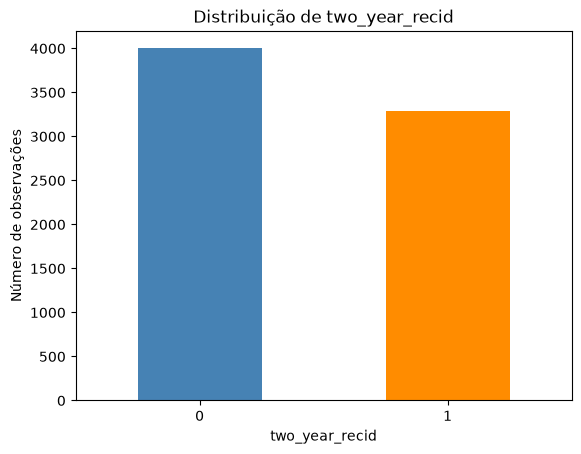

In [153]:
alvo = compas_two_year_recidivism["two_year_recid"]
contagens = alvo.value_counts().reindex([0, 1], fill_value=0)
proporcoes = contagens / contagens.sum()

distribuicao_alvo = pd.DataFrame({
    "contagem": contagens,
    "proporção": proporcoes,
    "percentual": (100 * proporcoes).round(2),
})
display(distribuicao_alvo)

print(f"Valores ausentes: {alvo.isna().sum()}")
print(
    "Baseline de accuracy ao prever sempre a classe maioritária: "
    f"{100 * proporcoes.max():.2f}%"
)

ax = contagens.plot(kind="bar", color=["steelblue", "darkorange"], rot=0)
ax.set(
    title="Distribuição de two_year_recid",
    xlabel="two_year_recid",
    ylabel="Número de observações",
)

In [154]:
dados_modelagem = compas_normalizado.drop(columns=["juvenile_total"]).copy()

faltantes_antes = int(dados_modelagem["juv_fel_count"].isna().sum())
dados_modelagem["juv_fel_count"] = dados_modelagem["juv_fel_count"].fillna(0)

print(f"NaN em juv_fel_count imputados com 0: {faltantes_antes}")
print("NaN restantes em juv_fel_count:", int(dados_modelagem["juv_fel_count"].isna().sum()))
print("'juvenile_total' removida:", "juvenile_total" not in dados_modelagem.columns)

NaN em juv_fel_count imputados com 0: 211
NaN restantes em juv_fel_count: 0
'juvenile_total' removida: True


In [155]:
priors_numeric = pd.to_numeric(
    compas_normalizado["priors_count"]
    .astype("string")
    .str.strip()
    .replace({"-": pd.NA, "?": pd.NA}),
    errors="coerce",
)

print(priors_numeric.describe())
display(priors_numeric.quantile([0.95, 0.99, 0.999]).to_frame("quantil"))

limite_priors = 60
outliers_priors = priors_numeric > limite_priors

print(f"Valores de priors_count acima de {limite_priors}: {int(outliers_priors.sum())}")

# Mantém a coluna numérica; marcadores inválidos e outliers passam a NaN.
compas_normalizado["priors_count"] = priors_numeric.mask(outliers_priors)

print(
    "Valores ausentes em priors_count após a limpeza:",
    int(compas_normalizado["priors_count"].isna().sum()),
)

count       6482.0
mean      3.784172
std      12.869522
min            0.0
25%            0.0
50%            2.0
75%            5.0
max          500.0
Name: priors_count, dtype: Float64


,quantil
0.950,14.0
0.990,23.0
0.999,38.0


Valores de priors_count acima de 60: 6
Valores ausentes em priors_count após a limpeza: 487


In [156]:
priors_valid = priors_numeric[priors_numeric.notna()]
sorted_unique = sorted(priors_valid.unique())
print(sorted_unique)  # vê onde está o hiato exatamente

[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(33.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(250.0), np.float64(500.0)]


In [157]:
q1, q3 = priors_valid.quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
print(upper_bound)

12.5


In [158]:
compas_normalizado.loc[priors_numeric > 60, "priors_count"] = pd.NA

In [159]:
race_map = {"african american": "african-american"}
compas_normalizado["race"] = compas_normalizado["race"].replace(race_map)

In [160]:
charge_degree_map = {"felony": "f", "misdemeanor": "m"}
compas_normalizado["c_charge_degree"] = compas_normalizado["c_charge_degree"].replace(charge_degree_map)

In [161]:
# Converter os marcadores de ausência e garantir que a coluna é numérica.
priors_para_imputacao = pd.to_numeric(
    compas_normalizado["priors_count"]
    .astype("string")
    .str.strip()
    .replace({"-": pd.NA, "?": pd.NA}),
    errors="coerce",
)

# Verificar o tamanho dos grupos com age_cat e c_charge_degree observados.
chaves_grupo = ["age_cat", "c_charge_degree"]
group_sizes = compas_normalizado.groupby(
    chaves_grupo, observed=True
).size()

print("Tamanhos dos grupos (do menor para o maior):")
display(group_sizes.sort_values().to_frame("n"))

grupos_pequenos = group_sizes[group_sizes <= 30]
if grupos_pequenos.empty:
    print("Todos os grupos têm mais de 30 observações.")
else:
    print("Grupos com 30 ou menos observações; as medianas podem ser instáveis:")
    display(grupos_pequenos.to_frame("n"))

# Imputar pela mediana do grupo; usar a mediana global como fallback.
mediana_grupo = priors_para_imputacao.groupby(
    [
        compas_normalizado["age_cat"],
        compas_normalizado["c_charge_degree"],
    ],
    observed=True,
).transform("median")

mediana_global = priors_para_imputacao.median()
compas_normalizado["priors_count_imputed"] = (
    priors_para_imputacao.fillna(mediana_grupo).fillna(mediana_global)
)

# A coluna original é redundante; manter a versão imputada idêntica para referência.
compas_normalizado["prior_offenses_imputed"] = (
    compas_normalizado["priors_count_imputed"]
)

print(f"Mediana global usada no fallback: {mediana_global}")
print(
    "Valores imputados:",
    int(priors_para_imputacao.isna().sum()),
)
print(
    "Ausências restantes em priors_count_imputed:",
    int(compas_normalizado["priors_count_imputed"].isna().sum()),
)

Tamanhos dos grupos (do menor para o maior):


n
age_cat         c_charge_degree      
less than 25    m                 363
greater than 45 m                 611
less than 25    f                 903
greater than 45 f                 912
25 - 45         m                1424
                f                2532

Todos os grupos têm mais de 30 observações.
Mediana global usada no fallback: 2.0
Valores imputados: 487
Ausências restantes em priors_count_imputed: 0


In [162]:
decile = pd.to_numeric(compas_normalizado["decile_score"], errors="coerce")
score_text = compas_normalizado["score_text"].astype("string").str.strip().str.lower()

# Resumo observado por score_text
consistency = compas_normalizado.assign(decile_score_numeric=decile).groupby(
    "score_text", observed=True
)["decile_score_numeric"].describe()

display(consistency[["min", "max", "count"]])

# Classificar cada decile_score válido segundo o esquema oficial
score_esperado = pd.Series(pd.NA, index=compas_normalizado.index, dtype="string")
score_esperado.loc[decile.between(1, 4)] = "low"
score_esperado.loc[decile.between(5, 7)] = "medium"
score_esperado.loc[decile.between(8, 10)] = "high"

decile_invalido = ~decile.between(1, 10)
score_inconsistente = decile_invalido | score_text.ne(score_esperado).fillna(True)

linhas_score_suspeitas = compas_normalizado.loc[score_inconsistente].copy()
print("Linhas com decile_score fora de 1–10:", int(decile_invalido.sum()))
print("Linhas suspeitas por inconsistência entre score_text e decile_score:",
      len(linhas_score_suspeitas))

display(
    linhas_score_suspeitas[
        ["id", "score_text", "decile_score"]
    ].assign(score_esperado=score_esperado.loc[linhas_score_suspeitas.index])
)

,min,max,count
score_text,,,
high,1.0,10.0,1349.0
low,0.0,23.0,3761.0
medium,5.0,23.0,1853.0


Linhas com decile_score fora de 1–10: 6
Linhas suspeitas por inconsistência entre score_text e decile_score: 15


,id,score_text,decile_score,score_esperado
20,5096,low,15,<NA>
31,3502,high,1,low
561,6803,high,2,low
567,9129,medium,23,<NA>
1143,8304,low,10,high
2321,9238,low,0,<NA>
3967,4812,low,9,high
4319,9088,low,0,<NA>
4699,9670,high,2,low
4971,2363,low,23,<NA>


In [163]:
mask_score_inconsistente = (
    score_esperado.notna()
    & score_esperado.ne(score_text).fillna(False)
)

inconsistencias_score = compas_normalizado.loc[
    mask_score_inconsistente, ["id", "score_text", "decile_score"]
].copy()
inconsistencias_score["score_esperado"] = score_esperado.loc[
    mask_score_inconsistente
]

print("Inconsistências entre score_text e decile_score:", len(inconsistencias_score))
display(inconsistencias_score)

Inconsistências entre score_text e decile_score: 9


,id,score_text,decile_score,score_esperado
31,3502,high,1,low
561,6803,high,2,low
1143,8304,low,10,high
3967,4812,low,9,high
4699,9670,high,2,low
5531,9023,high,1,low
5679,1882,low,9,high
6147,3255,high,2,low
6434,10807,low,9,high


In [164]:
compas_normalizado = compas_normalizado.dropna(subset=["score_text", "decile_score"])

In [165]:
age_numeric = pd.to_numeric(compas_normalizado["age"], errors="coerce")

bounds_violados = (
    ((compas_normalizado["age_cat"] == "less than 25") & (age_numeric >= 25)) |
    ((compas_normalizado["age_cat"] == "25 - 45") & ~age_numeric.between(25, 45)) |
    ((compas_normalizado["age_cat"] == "greater than 45") & (age_numeric <= 45))
)
print("Inconsistências age vs age_cat:", bounds_violados.sum())
display(compas_normalizado.loc[bounds_violados, ["age", "age_cat"]])

Inconsistências age vs age_cat: 195


,age,age_cat
118,NaN,25 - 45
127,NaN,25 - 45
144,45.0,greater than 45
237,45.0,greater than 45
251,45.0,greater than 45
...,...,...
6959,NaN,25 - 45
7039,45.0,greater than 45
7045,45.0,greater than 45
7198,NaN,25 - 45


In [166]:
bounds_violados = age_numeric.notna() & (
    ((compas_normalizado["age_cat"] == "less than 25") & (age_numeric >= 25)) |
    ((compas_normalizado["age_cat"] == "25 - 45") & ~age_numeric.between(25, 45)) |
    ((compas_normalizado["age_cat"] == "greater than 45") & (age_numeric <= 45))
)

In [167]:
age_numeric = pd.to_numeric(compas_normalizado["age"], errors="coerce")
age_cat = (
    compas_normalizado["age_cat"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Confirmar a convenção dos dados para age = 45.
age_45 = age_numeric.eq(45)
linhas_age_45 = compas_normalizado.loc[
    age_45, ["id", "age", "age_cat"]
].copy()

todas_45_em_greater_than_45 = (
    len(linhas_age_45) > 0
    and age_cat.loc[age_45].eq("greater than 45").all()
)

print(f"Linhas com age = 45: {len(linhas_age_45)}")
print(
    "Todas pertencem a 'greater than 45':",
    todas_45_em_greater_than_45,
)
display(linhas_age_45)

# Regra corrigida: 25–44 para "25 - 45"; 45 ou mais para "greater than 45".
bounds_violados = age_numeric.notna() & (
    ((age_cat == "less than 25") & (age_numeric >= 25))
    | ((age_cat == "25 - 45") & ~age_numeric.between(25, 44))
    | ((age_cat == "greater than 45") & (age_numeric < 45))
)

print("Inconsistências com a regra corrigida:", int(bounds_violados.sum()))
display(
    compas_normalizado.loc[bounds_violados, ["id", "age", "age_cat"]]
)

# Imputar age ausente com medianas por categoria, sem alterar age.
idades_validas = age_numeric.where(
    age_numeric.between(18, 100) & ~bounds_violados
)
mediana_global_age = idades_validas.median()
medianas_por_categoria = idades_validas.groupby(age_cat).transform("median")

compas_normalizado["age_imputed"] = (
    age_numeric.fillna(medianas_por_categoria).fillna(mediana_global_age)
)

print(f"Mediana global de age usada como fallback: {mediana_global_age}")
print(
    "Valores ausentes restantes em age_imputed:",
    int(compas_normalizado["age_imputed"].isna().sum()),
)

Linhas com age = 45: 107
Todas pertencem a 'greater than 45': True


,id,age,age_cat
144,8340,45.0,greater than 45
237,6192,45.0,greater than 45
251,2156,45.0,greater than 45
277,7308,45.0,greater than 45
511,10407,45.0,greater than 45
...,...,...,...
6797,2471,45.0,greater than 45
6928,1638,45.0,greater than 45
6955,9258,45.0,greater than 45
7039,1972,45.0,greater than 45


Inconsistências com a regra corrigida: 10


,id,age,age_cat
2047,9536,5.0,25 - 45
2307,2060,-3.0,25 - 45
2414,6482,5.0,25 - 45
2629,1023,59.0,less than 25
3249,2105,51.0,less than 25
3546,3023,-3.0,25 - 45
5410,3571,5.0,25 - 45
5936,45,55.0,less than 25
6486,1192,57.0,less than 25
6838,10035,53.0,less than 25


Mediana global de age usada como fallback: 31.0
Valores ausentes restantes em age_imputed: 0


In [168]:
decile_numeric = pd.to_numeric(compas_normalizado["decile_score"], errors="coerce")
compas_normalizado.loc[~decile_numeric.between(1, 10), "decile_score"] = pd.NA

age_numeric = pd.to_numeric(compas_normalizado["age"], errors="coerce")
compas_normalizado.loc[age_numeric.notna() & ~age_numeric.between(18, 100), "age"] = pd.NA

juv_fel_numeric = pd.to_numeric(compas_normalizado["juv_fel_count"], errors="coerce")
compas_normalizado.loc[juv_fel_numeric.notna() & (juv_fel_numeric < 0), "juv_fel_count"] = pd.NA
compas_normalizado["juv_fel_count"] = pd.to_numeric(compas_normalizado["juv_fel_count"], errors="coerce").fillna(0)

In [169]:
compas_normalizado["age"] = compas_normalizado["age"].fillna(compas_normalizado["age"].median())

In [170]:
compas_normalizado = compas_normalizado.dropna(subset=["c_charge_degree"])

In [171]:
compas_normalizado = compas_normalizado.drop(
    columns=["age_in_months", "prior_offenses", "priors_count", "juvenile_total"],
    errors="ignore",
)

In [172]:
# Missingness residual
print("Valores em falta por coluna:")
display(compas_normalizado.isna().sum()[compas_normalizado.isna().sum() > 0])

# Placeholders ainda presentes nalguma coluna de texto?
for col in compas_normalizado.select_dtypes(include=["object", "string"]).columns:
    tokens_restantes = compas_normalizado[col].astype("string").str.strip().str.lower().isin({"-", "?"}).sum()
    if tokens_restantes > 0:
        print(f"AINDA há tokens de missing em {col}: {tokens_restantes}")

# Duplicados
print("\nLinhas duplicadas:", compas_normalizado.duplicated().sum())
print("IDs duplicados:", compas_normalizado["id"].duplicated().sum())

# Domínio
decile_numeric = pd.to_numeric(compas_normalizado["decile_score"], errors="coerce")
print("\ndecile_score fora de [1,10]:", (decile_numeric.notna() & ~decile_numeric.between(1, 10)).sum())

age_numeric = pd.to_numeric(compas_normalizado["age"], errors="coerce")
print("age fora de [18,100]:", (age_numeric.notna() & ~age_numeric.between(18, 100)).sum())

for col in ["priors_count_imputed", "juv_fel_count", "juv_misd_count", "juv_other_count"]:
    numeric_col = pd.to_numeric(compas_normalizado[col], errors="coerce")
    print(f"{col} negativos:", (numeric_col < 0).sum())

# Categorias — confirmar que só sobra uma variante por grupo
for col in ["race", "sex", "c_charge_degree", "score_text"]:
    print(f"\n{col}:", sorted(compas_normalizado[col].dropna().unique()))

Valores em falta por coluna:


decile_score    6
dtype: int64


Linhas duplicadas: 0
IDs duplicados: 0

decile_score fora de [1,10]: 0
age fora de [18,100]: 0
priors_count_imputed negativos: 0
juv_fel_count negativos: 0
juv_misd_count negativos: 0
juv_other_count negativos: 0

race: ['african-american', 'asian', 'caucasian', 'hispanic', 'native american', 'other']

sex: ['female', 'male']

c_charge_degree: ['f', 'm']

score_text: ['high', 'low', 'medium']


In [173]:
numeric_cols = ["age", "priors_count_imputed", "juv_fel_count", "juv_misd_count",
                 "juv_other_count", "decile_score", "two_year_recid"]

corr_numeric = compas_normalizado[numeric_cols].corr()
display(corr_numeric.round(2))

,age,priors_count_imputed,juv_fel_count,juv_misd_count,juv_other_count,decile_score,two_year_recid
age,1.00,0.11,-0.06,-0.12,-0.15,-0.37,-0.18
priors_count_imputed,0.11,1.00,0.15,0.25,0.11,0.43,0.28
juv_fel_count,-0.06,0.15,1.00,0.08,0.04,0.17,0.09
juv_misd_count,-0.12,0.25,0.08,1.00,0.28,0.21,0.11
juv_other_count,-0.15,0.11,0.04,0.28,1.00,0.18,0.10
decile_score,-0.37,0.43,0.17,0.21,0.18,1.00,0.34
two_year_recid,-0.18,0.28,0.09,0.11,0.10,0.34,1.00


,age,priors_count_imputed,juv_fel_count,juv_misd_count,juv_other_count,decile_score,two_year_recid,sex,race,age_cat,c_charge_degree,score_text
age,1.00,0.11,-0.06,-0.12,-0.15,-0.37,-0.18,0.00,0.18,0.88,0.08,0.29
priors_count_imputed,0.11,1.00,0.15,0.25,0.11,0.43,0.28,0.11,0.20,0.20,0.15,0.41
juv_fel_count,-0.06,0.15,1.00,0.08,0.04,0.17,0.09,0.05,0.07,0.06,0.04,0.17
juv_misd_count,-0.12,0.25,0.08,1.00,0.28,0.21,0.11,0.04,0.10,0.11,0.03,0.22
juv_other_count,-0.15,0.11,0.04,0.28,1.00,0.18,0.10,0.05,0.06,0.17,0.03,0.18
decile_score,-0.37,0.43,0.17,0.21,0.18,1.00,0.34,0.05,0.31,0.33,0.18,0.93
two_year_recid,-0.18,0.28,0.09,0.11,0.10,0.34,1.00,0.09,0.12,0.16,0.10,0.32
sex,0.00,0.11,0.05,0.04,0.05,0.05,0.09,1.00,0.08,0.01,0.05,0.07
race,0.18,0.20,0.07,0.10,0.06,0.31,0.12,0.08,1.00,0.12,0.09,0.20
age_cat,0.88,0.20,0.06,0.11,0.17,0.33,0.16,0.01,0.12,1.00,0.08,0.18


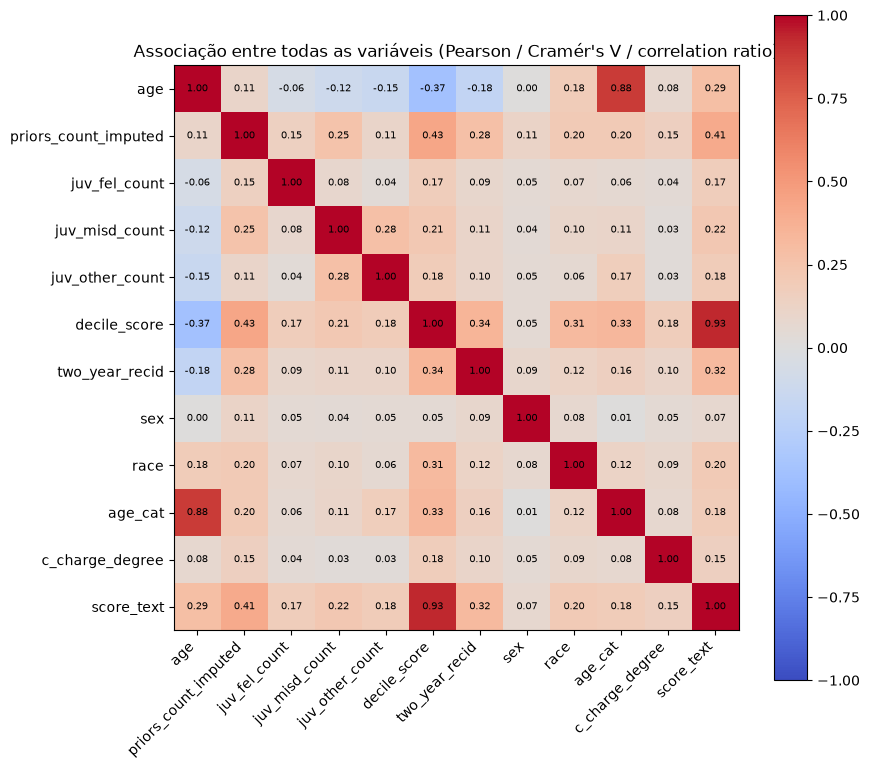

In [174]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

def correlation_ratio(categories, numeric):
    df_temp = pd.DataFrame({"cat": categories, "num": numeric}).dropna()
    grand_mean = df_temp["num"].mean()
    ss_between = df_temp.groupby("cat")["num"].apply(
        lambda g: len(g) * (g.mean() - grand_mean) ** 2
    ).sum()
    ss_total = ((df_temp["num"] - grand_mean) ** 2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else 0.0

categorical_cols = ["sex", "race", "age_cat", "c_charge_degree", "score_text"]
all_cols = numeric_cols + categorical_cols

assoc_matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

for col1 in all_cols:
    for col2 in all_cols:
        if col1 == col2:
            assoc_matrix.loc[col1, col2] = 1.0
        elif col1 in numeric_cols and col2 in numeric_cols:
            assoc_matrix.loc[col1, col2] = compas_normalizado[col1].corr(compas_normalizado[col2])
        elif col1 in categorical_cols and col2 in categorical_cols:
            assoc_matrix.loc[col1, col2] = cramers_v(compas_normalizado[col1], compas_normalizado[col2])
        else:
            cat_col, num_col = (col1, col2) if col1 in categorical_cols else (col2, col1)
            assoc_matrix.loc[col1, col2] = correlation_ratio(compas_normalizado[cat_col], compas_normalizado[num_col])

display(assoc_matrix.round(2))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(assoc_matrix.astype(float), cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(all_cols))); ax.set_xticklabels(all_cols, rotation=45, ha="right")
ax.set_yticks(range(len(all_cols))); ax.set_yticklabels(all_cols)
for i in range(len(all_cols)):
    for j in range(len(all_cols)):
        ax.text(j, i, f"{assoc_matrix.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im)
plt.title("Associação entre todas as variáveis (Pearson / Cramér's V / correlation ratio)")
plt.tight_layout()

,age,priors_count_imputed,juv_fel_count,juv_misd_count,juv_other_count,decile_score,two_year_recid
age,1.00,0.11,-0.06,-0.12,-0.15,-0.37,-0.18
priors_count_imputed,0.11,1.00,0.15,0.25,0.11,0.43,0.28
juv_fel_count,-0.06,0.15,1.00,0.08,0.04,0.17,0.09
juv_misd_count,-0.12,0.25,0.08,1.00,0.28,0.21,0.11
juv_other_count,-0.15,0.11,0.04,0.28,1.00,0.18,0.10
decile_score,-0.37,0.43,0.17,0.21,0.18,1.00,0.34
two_year_recid,-0.18,0.28,0.09,0.11,0.10,0.34,1.00


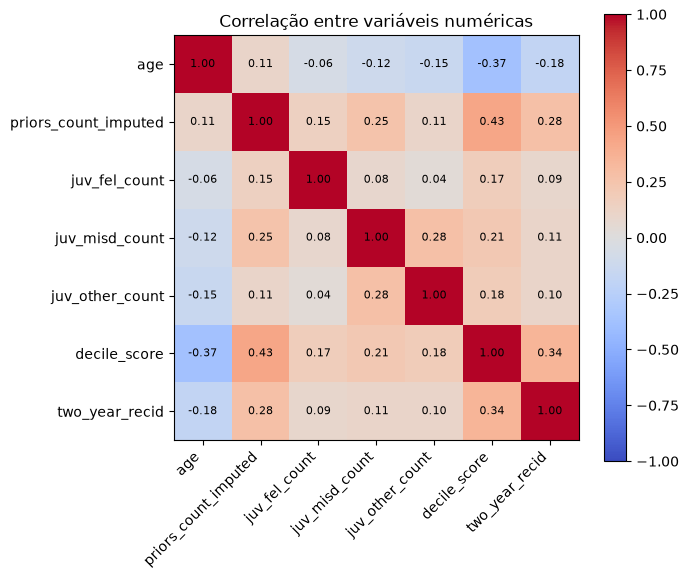

In [175]:
import numpy as np

numeric_cols = ["age", "priors_count_imputed", "juv_fel_count", "juv_misd_count",
                 "juv_other_count", "decile_score", "two_year_recid"]

corr = compas_normalizado[numeric_cols].corr()
display(corr.round(2))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols))); ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticks(range(len(numeric_cols))); ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im)
plt.title("Correlação entre variáveis numéricas")
plt.tight_layout()

In [176]:
for col in ["sex", "race", "age_cat", "c_charge_degree"]:
    display(compas_normalizado.groupby(col, observed=True)["two_year_recid"].agg(["mean", "count"]))

,mean,count
sex,,
female,0.358404,1303
male,0.466924,5442


,mean,count
race,,
african-american,0.505104,3429
asian,0.266667,30
caucasian,0.396552,2320
hispanic,0.356667,600
native american,0.500000,14
other,0.360795,352


,mean,count
age_cat,,
25 - 45,0.459555,3956
greater than 45,0.319107,1523
less than 25,0.556082,1266


,mean,count
c_charge_degree,,
f,0.483782,4347
m,0.377398,2398


In [179]:
feature_columns = [
    "age",
    "priors_count_imputed",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "sex",
    "c_charge_degree",
]
target_column = "two_year_recid"

X = compas_normalizado[feature_columns].copy()
y = compas_normalizado[target_column].copy()

# reservado só para a auditoria de fairness depois do treino -- nunca é usado como input do modelo
extras = compas_normalizado[["race", "score_text"]].copy()

print("Features do modelo:", X.columns.tolist())
print("Shape X:", X.shape, " Shape y:", y.shape)
display(X.head())

Features do modelo: ['age', 'priors_count_imputed', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'sex', 'c_charge_degree']
Shape X: (6745, 7)  Shape y: (6745,)


,age,priors_count_imputed,juv_fel_count,juv_misd_count,juv_other_count,sex,c_charge_degree
0,27.0,0.0,0.0,0,1,male,f
1,23.0,3.0,0.0,0,0,male,m
2,28.0,2.0,0.0,0,0,male,f
3,21.0,2.0,0.0,0,0,female,f
4,31.0,1.0,0.0,0,0,male,m
